# 02 — Entraînement du réseau


In [1]:
import numpy as np
import json

with open("params_simulation.json") as f:
    p = json.load(f)

L, Nx, Nt,t_end  = p["L"], p["Nx"], p["Nt"], p["t_end"]

PULSATIONS    = p["PULSATIONS"]
n_sims        = p["n_sims"]
E   = p["E"]
rho = p["rho"]
v   = np.sqrt(E / rho)
N=p["N"]
INPUTS=p["INPUTS"]
OUTPUTS=p["OUTPUTS"]

---
## 1. Paramètres

In [2]:
# Fichiers produits par le notebook 01
DATASET_FILE   = "wave_beam_dataset.csv"
NORMSTATS_FILE = "norm_stats.csv"

# Architecture du réseau
HIDDEN_SIZE = 32    # nombre de neurones par couche cachée
N_LAYERS    = 2     # nombre de couches cachées

# Entraînement
LEARNING_RATE = 1e-3
N_EPOCHS      = 10
BATCH_SIZE    = 512

---
## 2. Chargement des données

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Chargement du dataset et des stats de normalisation
df         = pd.read_csv(DATASET_FILE)
norm_stats = pd.read_csv(NORMSTATS_FILE, index_col=0)

#To check and visualise
print(f"Dataset : {len(df):,} lignes")
print(f"Splits  : {df['split'].value_counts().to_dict()}")

# Colonnes normalisées
INPUTS_N = [f"{x}_n" for x in INPUTS]
OUTPUTS_N = [f"{x}_n" for x in OUTPUTS]

# Extraction train / val en utilisant la colonne split du dataset
train_mask = df["split"] == "train"
val_mask   = df["split"] == "val"

X_train = df.loc[train_mask, INPUTS_N].values.astype(np.float32)
y_train = df.loc[train_mask, OUTPUTS_N].values.astype(np.float32)

X_val   = df.loc[val_mask, INPUTS_N].values.astype(np.float32)
y_val   = df.loc[val_mask, OUTPUTS_N].values.astype(np.float32)

print(f"\nTrain : {len(X_train):,} exemples")
print(f"Val   : {len(X_val):,} exemples")

# Conversion en tenseurs PyTorch et création des DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE
)

Dataset : 233,632 lignes
Splits  : {'train': 146020, 'test': 58408, 'val': 29204}

Train : 146,020 exemples
Val   : 29,204 exemples


---
## 3. Network defintion


In [4]:
class Reseau(nn.Module):

    def __init__(self, n_inputs, n_outputs, hidden_size, n_layers):
        super().__init__()

        couches = []
        taille_entree = n_inputs

        for _ in range(n_layers):
            couches.append(nn.Linear(taille_entree, hidden_size))  # couche linéaire
            couches.append(nn.Tanh())                              # activation non-linéaire
            taille_entree = hidden_size

        couches.append(nn.Linear(hidden_size, n_outputs))  # couche de sortie

        self.reseau = nn.Sequential(*couches)

    def forward(self, x):
        return self.reseau(x)


modele = Reseau(
    n_inputs    = len(INPUTS_N), 
    n_outputs   = len(OUTPUTS_N),   
    hidden_size = HIDDEN_SIZE,
    n_layers    = N_LAYERS,
)

n_params = sum(p.numel() for p in modele.parameters())
print(modele)
print(f"\nNombre de paramètres : {n_params:,}")

Reseau(
  (reseau): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Nombre de paramètres : 1,313


---
## 4. Training

Epoch    2/10  —  train: 0.0118  |  val: 0.0005  
Epoch    4/10  —  train: 0.0020  |  val: 0.0002  
Epoch    6/10  —  train: 0.0008  |  val: 0.0000  
Epoch    8/10  —  train: 0.0004  |  val: 0.0000  
Epoch   10/10  —  train: 0.0003  |  val: 0.0000  


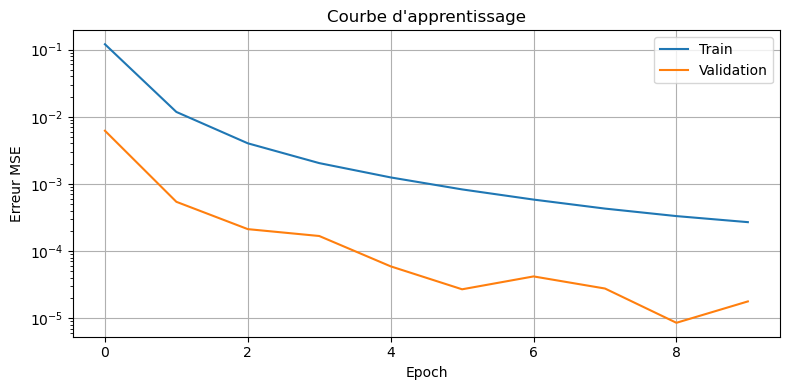

Meilleur modèle rechargé — val minimale : 0.000009


In [5]:
criterion  = nn.MSELoss()   # erreur quadratique moyenne
optimiseur = torch.optim.Adam(modele.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiseur, mode="min", factor=0.5, patience=10
)

historique_train = []
historique_val   = []

meilleure_val = float("inf")   # on initialise au pire score possible
patience_compteur = 0          # on verra ça après

for epoch in range(1, N_EPOCHS + 1):

    # Phase entraînement
    modele.train()
    perte_train = 0.0       #initialisation of training loss
    for X_batch, y_batch in train_loader:
        optimiseur.zero_grad()                       # remet les gradients à zéro
        prediction = modele(X_batch)                 # prédiction
        perte      = criterion(prediction, y_batch)  # erreur
        perte.backward()                             # rétropropagation
        optimiseur.step()                            # mise à jour des poids
        perte_train += perte.item()
    perte_train /= len(train_loader)

    # Phase validation : un seul forward pass sur tout le val
    modele.eval()
    with torch.no_grad():
        pred_val = modele(torch.tensor(X_val)).numpy()

    # Loss globale 
    perte_val = ((pred_val - y_val)**2).mean()
    scheduler.step(perte_val)

    # Loss par output
    historique_train.append(perte_train)
    historique_val  .append(perte_val)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:4d}/{N_EPOCHS}  —  "
            f"train: {perte_train:.4f}  |  "
            f"val: {perte_val:.4f}  ")
    
    # Si la val s'est améliorée, on sauvegarde ce modèle
    if perte_val < meilleure_val:
        meilleure_val = perte_val
        torch.save(modele.state_dict(), "model.pth")   # on écrase avec le meilleur

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historique_train, label="Train")
ax.plot(historique_val,   label="Validation")
ax.set_xlabel("Epoch") ; ax.set_ylabel("Erreur MSE")
ax.set_title("Courbe d'apprentissage")
ax.set_yscale("log")
ax.legend() ; ax.grid(True)
plt.tight_layout() ; plt.show()

# On recharge le meilleur modèle trouvé pendant l'entraînement
modele.load_state_dict(torch.load("model.pth",weights_only=True ))
print(f"Meilleur modèle rechargé — val minimale : {meilleure_val:.6f}")

---
## Vérification

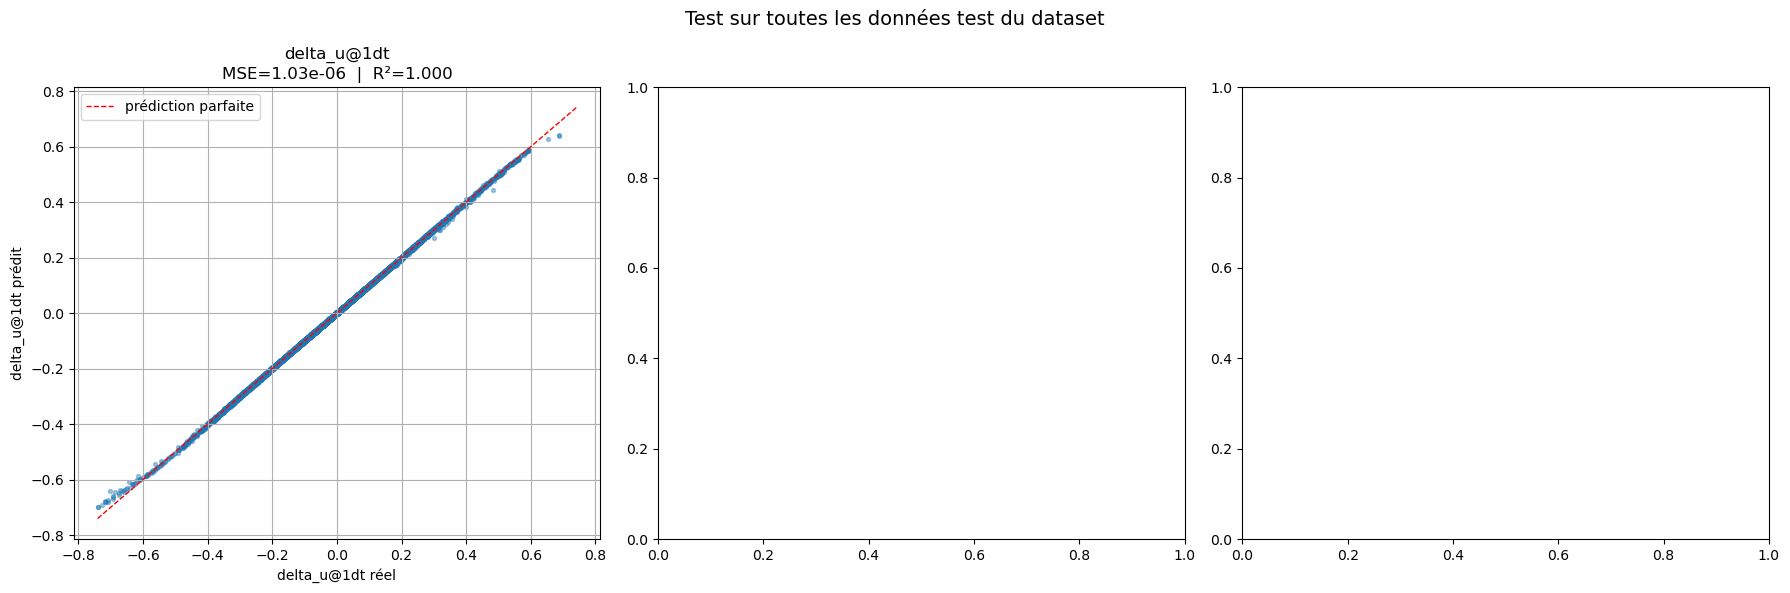

delta_u@1dt     : MSE = 1.0335e-06  |  R² = 0.9998


In [6]:
# --- 1. Choisir des paramètres ---
df_test=df[df["split"]=="test"].reset_index(drop=True)

X_new  = df_test[[c + "_n" for c in INPUTS]].values.astype(np.float32)
y_true = df_test[OUTPUTS].values   # shape (N, 3)

# --- 4. Prédiction ---
modele.eval()
with torch.no_grad():
    y_pred_n = modele(torch.tensor(X_new)).numpy()   # shape (N, 3)

# Dénormalisation colonne par colonne
y_pred = np.zeros_like(y_pred_n)
for i, col in enumerate(OUTPUTS):
    mean_du = norm_stats.loc[col, "mean"]
    std_du  = norm_stats.loc[col, "std"]
    y_pred[:, i] = y_pred_n[:, i] * std_du + mean_du

# --- 5. Visualisation : une figure par sortie ---
n_cols = 3                                              # 3 figures par ligne
n_rows = (len(OUTPUTS) + n_cols - 1) // n_cols          # nombre de lignes nécessaires
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
axes = axes.flatten()                                   # pour pouvoir itérer en 1D

for i, (ax, col) in enumerate(zip(axes, OUTPUTS)):
    y_r = y_true[:, i]
    y_p = y_pred[:, i]
    
    ax.scatter(y_r, y_p, alpha=0.4, s=8)
    lim = max(abs(y_r).max(), abs(y_p).max())
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1, label="prédiction parfaite")
    
    ax.set_xlabel(f"{col} réel")
    ax.set_ylabel(f"{col} prédit")
    
    mse = ((y_p - y_r)**2).mean()
    r2  = 1 - mse / y_r.var()
    ax.set_title(f"{col}\nMSE={mse:.2e}  |  R²={r2:.3f}")
    ax.legend()
    ax.grid(True)

fig.suptitle("Test sur toutes les données test du dataset", fontsize=14)
plt.tight_layout()
plt.show()

# --- 6. Métriques globales ---
for i, col in enumerate(OUTPUTS):
    mse = ((y_pred[:,i] - y_true[:,i])**2).mean()
    r2  = 1 - mse / y_true[:,i].var()
    print(f"{col:15s} : MSE = {mse:.4e}  |  R² = {r2:.4f}")

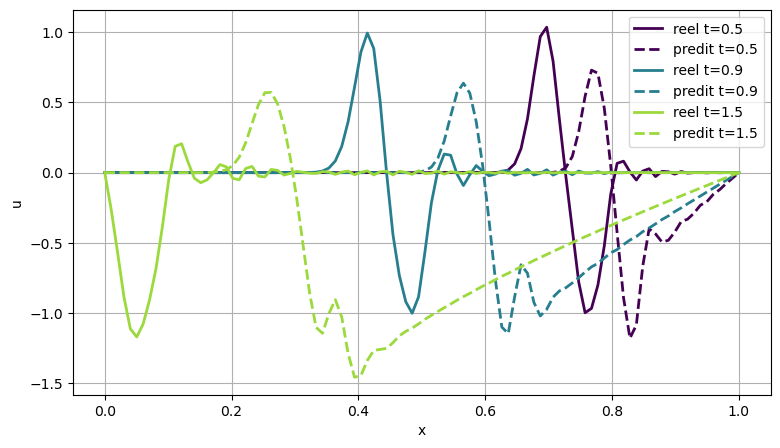

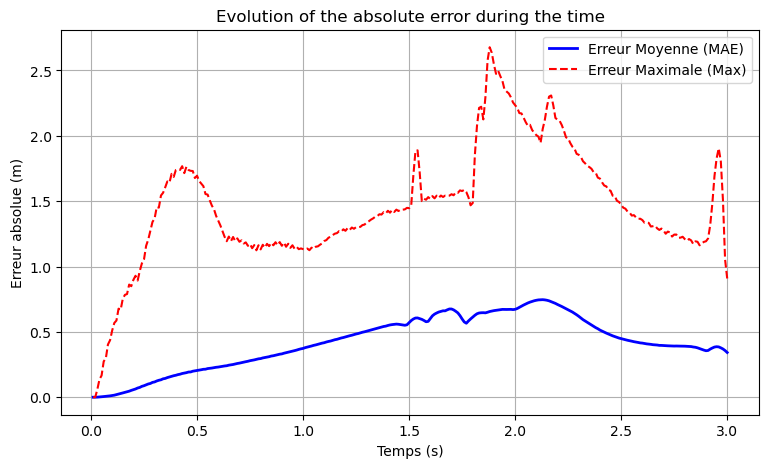

In [18]:
# Roll out cell

omega = PULSATIONS[2]
dx = L / (Nx - 1)
dt = t_end / Nt
t_list = [0.5, 0.9, 1.5]
x = np.linspace(0, L, Nx)

c=np.sqrt(E/rho)

dx_bar=dx/L
dt_bar=dt*c/L
omega_bar=omega*L/c
CFL_bar=dt_bar/dx_bar

def past_label(k):
    if k == 0: return "@t"
    if k == 1: return "@t-dt"
    return f"@t-{k}dt"

stats_normalisation = {}
for name in INPUTS + OUTPUTS:
    stats_normalisation[name] = {
        "mean": norm_stats.loc[name, "mean"],
        "std" : norm_stats.loc[name, "std"]
    }

mu_du = stats_normalisation[OUTPUTS[0]]["mean"]
sd_du = stats_normalisation[OUTPUTS[0]]["std"]

noms_features = [c[:-2] for c in INPUTS_N]   

t_pulse_bar     = 2 * np.pi / omega_bar
def u_bar_right(t_bar):
    return np.sin(omega_bar * t_bar) if t_bar < t_pulse_bar else 0.0

def construire_entree(champs, noeuds):
    e = np.zeros((len(noeuds), len(noms_features)), dtype=np.float32)
    for idx, name in enumerate(noms_features):
        mu = stats_normalisation[name]["mean"]
        sd = stats_normalisation[name]["std"]
        e[:, idx] = (champs[name][noeuds] - mu) / sd
    return e

# =====================================================
# 1) VRAIE simulation (physique)
# =====================================================

u   = np.zeros(Nx)
u_2 = np.zeros(Nx)
reel = {0.0: u.copy()}
for n in range(Nt):
    tn_bar = n * dt_bar
    u_new = np.zeros(Nx)
    u_new[1:-1] = 2*u[1:-1] - u_2[1:-1] + CFL_bar**2 * (u[2:] - 2*u[1:-1] + u[:-2])
    u_new[0]  = 0.0
    u_new[-1] = u_bar_right(tn_bar)
    u_2 = u.copy()
    u   = u_new
    reel[round((n+1)*dt, 5)] = u.copy()

# =====================================================
# 2) Simulation PREDITE (reseau)
# =====================================================

u   = np.zeros(Nx)
u_1 = np.zeros(Nx)
pred = {0.0: u.copy()}

error_mae=np.zeros(Nt)
error_max=np.zeros(Nt)
temps_sim=np.zeros(Nt)

valid = np.arange(1,Nx-1)

# Biais au repos (toutes features nulles)
champs_repos = {name: np.zeros(Nx) for name in noms_features}
with torch.no_grad():
    sortie_repos = modele(torch.tensor(construire_entree(champs_repos, valid))).numpy().ravel()
bias_repos = (sortie_repos * sd_du + mu_du)[0]   # scalaire

u_xx_storage    =np.zeros((Nt,Nx))
u_dot_storage   =np.zeros((Nt,Nx))

for n in range(Nt):
    tn_bar = n * dt_bar
    t_suivant = round((n+1)*dt,5)

    u_xx = np.zeros(Nx)
    u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx_bar**2
    u_dot = (u - u_1) / dt_bar                       

    u_xx_storage[n]   =u_xx
    u_dot_storage[n]  =u_dot

    champs = {}

    for k in range(N):
        idx=max(0,n-k)
        champs[f"u_dot{past_label(k)}"]=u_dot_storage[idx]
        champs[f"u_xx{past_label(k)}"]=u_xx_storage[idx]


    with torch.no_grad():
        sortie = modele(torch.tensor(construire_entree(champs, valid))).numpy().ravel()
    delta_u = sortie * sd_du + mu_du - bias_repos

    u_new = u.copy()
    u_new[valid] = u[valid] + delta_u
    u_new[0]  = 0.0
    u_new[-1] = u_bar_right(tn_bar)

    u_1 = u.copy()
    u   = u_new

    pred[t_suivant] = u.copy()

    u_reel_instante=reel[t_suivant]

    error_mae[n]=np.mean(np.abs(u_reel_instante-u_new))
    error_max[n]=np.max(np.abs(u_reel_instante-u_new))
    temps_sim[n]=t_suivant

# =====================================================
# 3) Trace
# =====================================================
plt.figure(figsize=(9, 5))
for t, col in zip(t_list, plt.cm.viridis(np.linspace(0, 0.85, len(t_list)))):
    kr = min(reel, key=lambda k: abs(k - t))
    kp = min(pred, key=lambda k: abs(k - t))
    plt.plot(x, reel[kr], color=col, lw=2, label=f"reel t={t}")
    plt.plot(x, pred[kp], color=col, lw=2, ls="--", label=f"predit t={t}")

plt.xlabel("x"); plt.ylabel("u"); plt.legend(); plt.grid(True)
plt.show()


plt.figure(figsize=(9, 5))

plt.plot(temps_sim, error_mae, label="Erreur Moyenne (MAE)", color="blue", lw=2)
plt.plot(temps_sim, error_max, label="Erreur Maximale (Max)", color="red", lw=1.5, ls="--")

plt.xlabel("Temps (s)")
plt.ylabel("Erreur absolue (m)"); 
plt.title("Evolution of the absolute error during the time")
plt.legend()
plt.grid(True)
plt.show()

